# Taxi

Deze code toont een intelligent agent met zelflerend gedrag, zoals gezien in de les over reinforcement learning. De agent wordt gaandeweg beter in het oppikken van rewards. Het centrale onderdeel in dit algoritme is het 'Q-learning algoritme'. Dit werkt als volgt:

**Initialisatie van de Q-tabel**
- Maakt een Q-tabel aan met nullen, bedoeld voor het bijhouden van beloningen.

**Instellen van Q-learning Parameters**
- Stelt leerparameters in zoals `learning_rate`, `discount_factor`, `num_episodes`, en `max_steps_per_episode`.

**Q-learning Algoritme**
- *Loop door Episodes:* elke episode begint met het resetten van de omgeving.
- *Handeling:* kiest tussen exploratie en exploitatie, waarbij de kans op exploratie afneemt naarmate er meer episodes zijn voltooid.
- *Actie en Observatie:* voert een actie uit en observeert de uitkomst en beloning.
- *Update van de Q-tabel:* past de Q-tabel aan op basis van de ontvangen beloning.

In essentie is de Q-tabel een lijst van 'locaties' in state-space waar een beloning werd gevonden.

**Beloningen Opslaan en Analyseren**
- Slaat de beloningen op en berekent de gemiddelde beloning over alle episodes.

**Resultaten Plotten**
- Toont een grafiek van de beloningen per episode over tijd.


Average Reward: -214.469


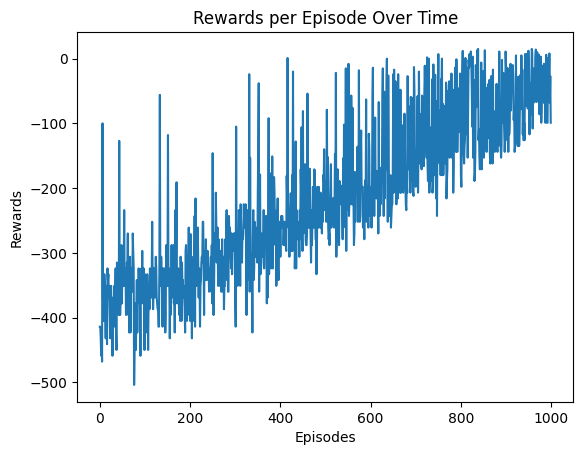

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# Omgeving opzetten
env = gym.make('Taxi-v3')

# Initialisatie the Q-table
Q_table = np.zeros([env.observation_space.n, env.action_space.n])

# Q-learning parameters
learning_rate = 0.1
discount_factor = 0.9
num_episodes = 1000
max_steps_per_episode = 99

# om later matrices te plotten
rewards_all_episodes = []

# Q-learning algoritme
for episode in range(num_episodes):
    initial_state = env.reset()
    state = initial_state[0] if isinstance(initial_state, tuple) else initial_state  # integer eruit vissen
    total_rewards = 0

    for step in range(max_steps_per_episode):
        # Exploratie vs exploitatie
        exploration_rate = 1 - episode / num_episodes # in het begin een veel grotere kans op exploratie
        #exploration_rate = np.exp(-episode/num_episodes)
        if np.random.uniform(0, 1) < exploration_rate:
            action = env.action_space.sample() # random kiezen, exploratie
        else:
            action = np.argmax(Q_table[state, :]) # doe de beste gekende actie

        # Actie uitvoeren, resultaat observeren
        new_state, reward, terminated, truncated, _ = env.step(action)

        # Update Q-table
        Q_table[state, action] = Q_table[state, action] * (1 - learning_rate) + \
                                 learning_rate * (reward + discount_factor * np.max(Q_table[new_state, :]))

        total_rewards += reward
        state = new_state

        if terminated or truncated:
            break

    rewards_all_episodes.append(total_rewards)

# berekening en prints
average_reward = sum(rewards_all_episodes) / num_episodes
print(f"Average Reward: {average_reward}")

# Plotting the learning progress
plt.plot(rewards_all_episodes)
plt.xlabel('Episodes')
plt.ylabel('Rewards')
plt.title('Rewards per Episode Over Time')
plt.show()
